In [1]:
# Name: Chhayank Sharma
# Registration no.: 60
# Demo given to introduce data visualisation basics for DAV lab

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sp = pd.DataFrame(pd.read_csv('StudentsPerformance.csv'))
sp

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
sp.loc[:,['math score', 'reading score']].head()

,math score,reading score
0,72,72
1,69,90
2,90,95
3,47,57
4,76,78


In [7]:
sp.loc[sp['test preparation course'] == 'completed', ['math score', 'reading score']].head()

,math score,reading score
1,69,90
6,88,95
8,64,64
13,78,72
18,46,42


In [5]:
sp.iloc[0:5, :]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
sp.iloc[0:5, -3:]

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [11]:
sp.shape

(1000, 8)

In [12]:
sp.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


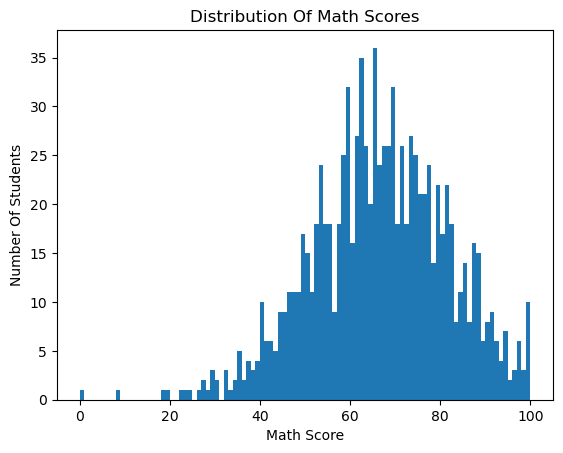

In [22]:
plt.hist(sp['math score'], bins = 100)
plt.xlabel('Math Score')
plt.ylabel('Number Of Students')
plt.title('Distribution Of Math Scores')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

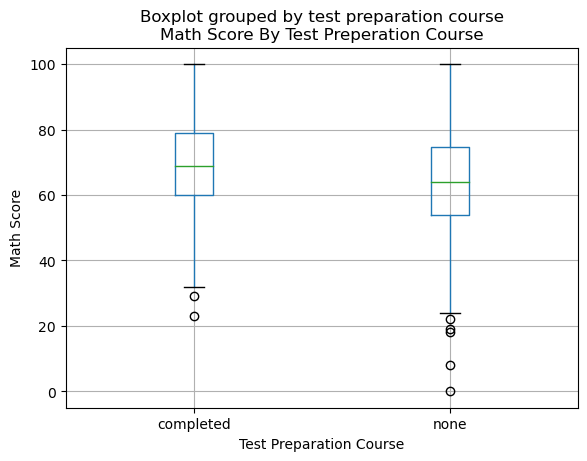

In [25]:
sp.boxplot(column='math score', by = 'test preparation course')
plt.title('Math Score By Test Preperation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.show

#### `Outliers Lie outside of (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)`

In [29]:
Q1 = sp['math score'].quantile(0.25)
Q3 = sp['math score'].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = sp[(sp['math score'] < lower) | (sp['math score'] > upper)]

print('outlier count: ', outliers.shape[0])
outliers[['math score', 'reading score', 'writing score']].head()

outlier count:  8


,math score,reading score,writing score
17,18,32,28
59,0,17,10
145,22,39,33
338,24,38,27
466,26,31,38


In [30]:
sp_no_out = sp[(sp['math score'] >= lower) & (sp['math score'] <= upper)]
sp_no_out.shape

(992, 8)

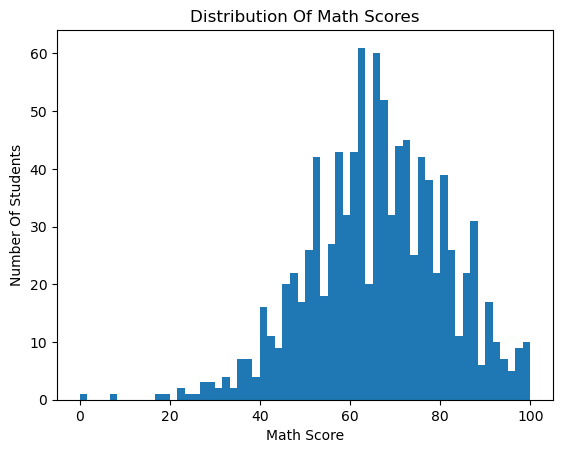

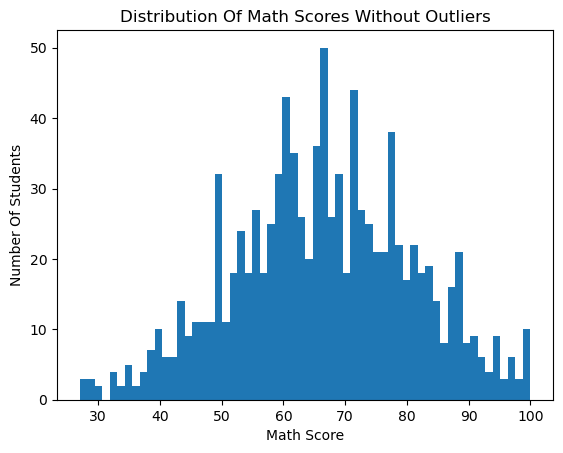

In [33]:
plt.hist(sp['math score'], bins = 60)
plt.xlabel('Math Score')
plt.ylabel('Number Of Students')
plt.title('Distribution Of Math Scores')
plt.show()

plt.hist(sp_no_out['math score'], bins = 60)
plt.xlabel('Math Score')
plt.ylabel('Number Of Students')
plt.title('Distribution Of Math Scores Without Outliers')
plt.show()

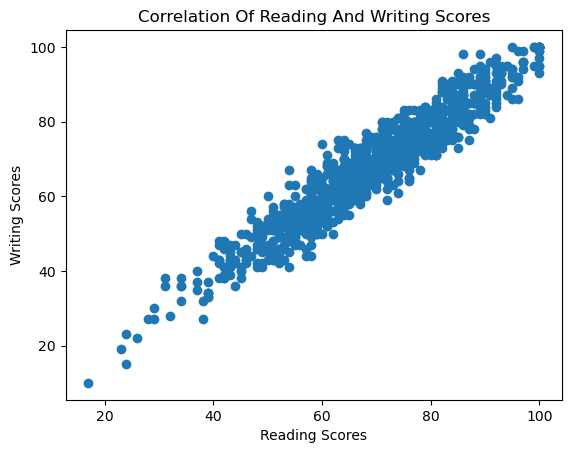

In [40]:
plt.scatter(sp['reading score'], sp['writing score'])
plt.xlabel('Reading Scores')
plt.ylabel('Writing Scores')
plt.title('Correlation Of Reading And Writing Scores')
plt.show()